# CICIDS 2017 — Intrusion Detection System: Full ML Pipeline

**Dataset:** CIC-IDS-2017 (Canadian Institute for Cybersecurity)  
**Goal:** Multi-class classification of network traffic (Benign vs. various attack types)  
**Pipeline:** Data Loading → Stratified Sampling → EDA → Feature Engineering → Preprocessing → Train/Val/Test Split → Modelling → Cross-Validation → Result Analysis

---

## Dataset Overview

| Property | Value |
|---|---|
| Records | ~2.8 million (we sample a manageable stratified subset) |
| Features | 78 numerical + 1 Label |
| Attack Types | DoS, DDoS, Brute Force, Heartbleed, Botnet, Web Attack, Infiltration, Benign |
| Days Covered | Monday–Friday, July 3–7, 2017 |
| Files | 8 CSV files (one per day/capture) |

> **Note on sampling:** The full 2.8M-row dataset is impractical for local experimentation. We load all files but immediately take a **stratified random sample** that preserves class distribution. The `SAMPLE_SIZE` constant controls this — adjust based on your RAM.

## 0. Install & Import Dependencies

In [5]:
import os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, f1_score, precision_score, recall_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='darkgrid', palette='muted')

# ── Global constants ──────────────────────────────────────────────────
RANDOM_STATE = 42

# How many rows to keep after stratified sampling.
# 150_000 is comfortable on most 8 GB laptops.
# Increase to 300_000 or set to None to use the full dataset.
SAMPLE_SIZE = 150_000

# Split ratios — must sum to 1.0
TRAIN_RATIO = 0.70   # 70%  training
VAL_RATIO   = 0.15   # 15%  validation  (hyper-param selection)
TEST_RATIO  = 0.15   # 15%  test        (final held-out evaluation)

print('Libraries imported.')
print(f'Sample size : {SAMPLE_SIZE:,}')
print(f'Split       : {int(TRAIN_RATIO*100)}/{int(VAL_RATIO*100)}/{int(TEST_RATIO*100)}  train/val/test')

Libraries imported.
Sample size : 150,000
Split       : 70/15/15  train/val/test


---
## 1. Data Loading

In [8]:
DATA_DIR = r"C:\Users\Gaurav Kumar Saha\Desktop\MachineLearningCVE"

csv_files = sorted([f for f in os.listdir(DATA_DIR) if f.endswith('.csv') or '_ISCX' in f])
print(f'Found {len(csv_files)} file(s):')
for f in csv_files:
    print(f'  {f}')

Found 8 file(s):
  Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
  Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
  Friday-WorkingHours-Morning.pcap_ISCX.csv
  Monday-WorkingHours.pcap_ISCX.csv
  Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
  Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
  Tuesday-WorkingHours.pcap_ISCX.csv
  Wednesday-workingHours.pcap_ISCX.csv


In [10]:
# Loading and concatenating all files
dfs = []
for fname in csv_files:
    fpath = os.path.join(DATA_DIR, fname)
    tmp = pd.read_csv(fpath, low_memory=False)
    tmp.columns = tmp.columns.str.strip()   # strip leading/trailing spaces
    dfs.append(tmp)
    print(f'  {fname}: {tmp.shape}')

df_full = pd.concat(dfs, ignore_index=True)
print(f'\nRaw combined shape: {df_full.shape}')
del dfs

  Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv: (225745, 79)
  Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv: (286467, 79)
  Friday-WorkingHours-Morning.pcap_ISCX.csv: (191033, 79)
  Monday-WorkingHours.pcap_ISCX.csv: (529918, 79)
  Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv: (288602, 79)
  Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv: (170366, 79)
  Tuesday-WorkingHours.pcap_ISCX.csv: (445909, 79)
  Wednesday-workingHours.pcap_ISCX.csv: (692703, 79)

Raw combined shape: (2830743, 79)


In [11]:
# Normalizing label column name
label_col = [c for c in df_full.columns if 'label' in c.lower()][0]
df_full.rename(columns={label_col: 'Label'}, inplace=True)
print('Raw class distribution:')
print(df_full['Label'].value_counts().to_string())

Raw class distribution:
Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11


In [7]:
# ── Stratified sampling ───────────────────────────────────────────────
# Each class is sampled proportionally; tiny classes get at least 30 rows.

if SAMPLE_SIZE is None or SAMPLE_SIZE >= len(df_full):
    df = df_full.copy()
    print(f'Using full dataset: {df.shape}')
else:
    counts      = df_full['Label'].value_counts()
    proportions = counts / counts.sum()
    per_class_n = (proportions * SAMPLE_SIZE).astype(int).clip(lower=30)

    sampled = []
    for label, n in per_class_n.items():
        pool     = df_full[df_full['Label'] == label]
        n_actual = min(n, len(pool))
        sampled.append(pool.sample(n_actual, random_state=RANDOM_STATE))

    df = (pd.concat(sampled, ignore_index=True)
            .sample(frac=1, random_state=RANDOM_STATE)
            .reset_index(drop=True))
    print(f'Stratified sample shape: {df.shape}')
    print('\nSampled class distribution:')
    print(df['Label'].value_counts().to_string())

del df_full

Stratified sample shape: (150053, 79)

Sampled class distribution:
Label
BENIGN                        120450
DoS Hulk                       12244
PortScan                        8421
DDoS                            6784
DoS GoldenEye                    545
FTP-Patator                      420
SSH-Patator                      312
DoS slowloris                    307
DoS Slowhttptest                 291
Bot                              104
Web Attack � Brute Force          79
Web Attack � XSS                  34
Infiltration                      30
Web Attack � Sql Injection        21
Heartbleed                        11


---
## 2. Exploratory Data Analysis (EDA)

In [8]:
# 2.1  Shape & dtypes
print('Shape:', df.shape)
print('\nDtype counts:')
print(df.dtypes.value_counts())
df.head(3)

Shape: (150053, 79)

Dtype counts:
int64      54
float64    24
object      1
Name: count, dtype: int64


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,53,32202,1,1,53,108,53,53,53.0000,0.0000,108,108,108.0000,0.0000,4999.6895,62.1079,32202.0000,0.0000,32202,32202,0,0.0000,0.0000,0,0,0,0.0000,0.0000,0,0,0,0,0,0,32,32,31.0540,31.0540,53,108,71.3333,31.7543,1008.3333,0,0,0,0,0,0,0,0,1,107.0000,53.0000,108.0000,32,0,0,0,0,0,0,1,53,1,108,-1,-1,0,32,0.0000,0.0000,0,0,0.0000,0.0000,0,0,BENIGN
1,60346,3,2,0,12,0,6,6,6.0000,0.0000,0,0,0.0000,0.0000,4000000.0000,666666.6667,3.0000,0.0000,3,3,3,3.0000,0.0000,3,3,0,0.0000,0.0000,0,0,0,0,0,0,40,0,666666.6667,0.0000,6,6,6.0000,0.0000,0.0000,0,0,0,0,1,0,0,0,0,9.0000,6.0000,0.0000,40,0,0,0,0,0,0,2,12,0,0,184,-1,1,20,0.0000,0.0000,0,0,0.0000,0.0000,0,0,BENIGN
2,80,1439758,3,5,26,11607,20,0,8.6667,10.2632,5840,0,2321.4000,3173.3739,8079.8301,5.5565,205679.7143,543812.7299,1438931,3,617,308.5000,368.4026,569,48,1439709,359927.2500,719335.8806,1438931,3,0,0,0,0,72,112,2.0837,3.4728,0,5840,1292.5556,2554.1592,6523729.2780,0,0,0,1,0,0,0,0,1,1454.1250,8.6667,2321.4000,72,0,0,0,0,0,0,3,26,5,11607,8192,229,2,20,0.0000,0.0000,0,0,0.0000,0.0000,0,0,DDoS


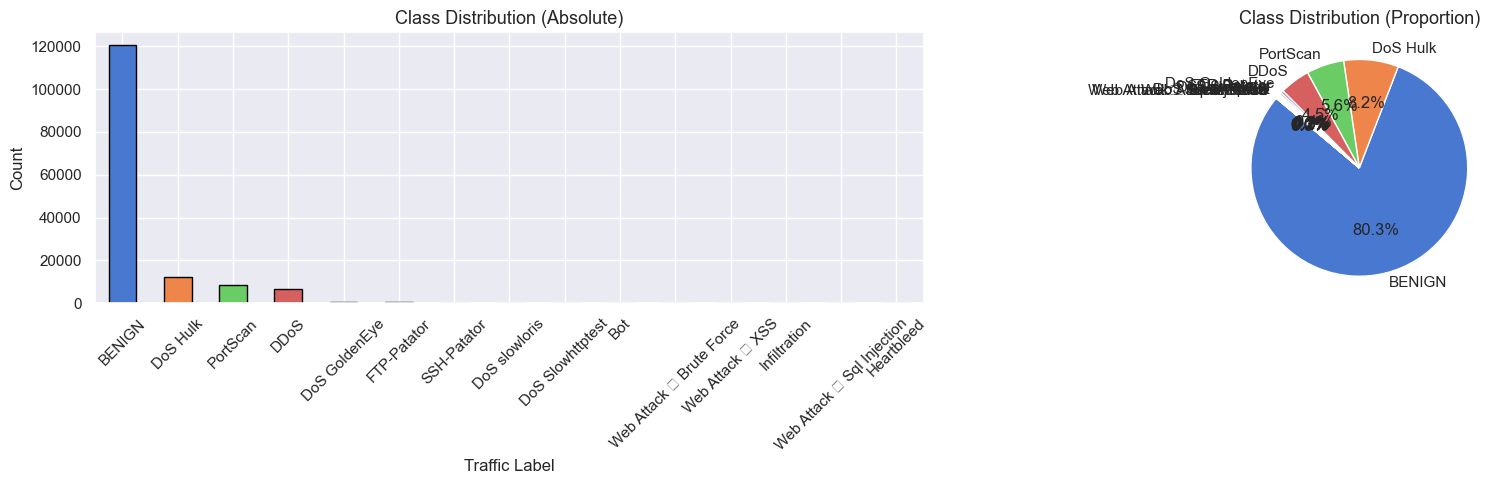

In [9]:
# 2.2  Class distribution (bar + pie)
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
counts = df['Label'].value_counts()
palette = sns.color_palette('muted', len(counts))

counts.plot(kind='bar', ax=axes[0], color=palette, edgecolor='black')
axes[0].set_title('Class Distribution (Absolute)', fontsize=13)
axes[0].set_xlabel('Traffic Label')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
            startangle=140, colors=palette)
axes[1].set_title('Class Distribution (Proportion)', fontsize=13)
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# 2.3  Missing values & infinities
inf_count = np.isinf(df.select_dtypes(include=np.number)).sum().sum()
nan_count = df.isnull().sum().sum()
print(f'NaN values : {nan_count}')
print(f'Inf values : {inf_count}')
missing = df.isnull().sum()
missing = missing[missing > 0]
if len(missing):
    print('\nColumns with NaN:')
    print(missing)
else:
    print('\nNo columns with NaN.')

NaN values : 68
Inf values : 180

Columns with NaN:
Flow Bytes/s    68
dtype: int64


In [11]:
# 2.4  Statistical summary — top-20 by std
df.describe().T.sort_values('std', ascending=False).head(20)

,count,mean,std,min,25%,50%,75%,max
Fwd Header Length.1,150053.0000,-216683.6553,83158630.3931,-32212234632.0000,40.0000,64.0000,120.0000,4340524.0000
Fwd Header Length,150053.0000,-216683.6553,83158630.3931,-32212234632.0000,40.0000,64.0000,120.0000,4340524.0000
Flow Duration,150053.0000,14779878.9037,33649250.7791,-1.0000,155.0000,31357.0000,3262027.0000,119999961.0000
Fwd IAT Total,150053.0000,14466003.7186,33569453.6589,0.0000,0.0000,45.0000,1211073.0000,120000000.0000
Bwd IAT Total,150053.0000,9877963.8754,28710526.2309,0.0000,0.0000,3.0000,99146.0000,120000000.0000
Fwd IAT Max,150053.0000,8998919.5833,24469955.8327,0.0000,0.0000,45.0000,892822.0000,120000000.0000
Flow IAT Max,150053.0000,9151410.5378,24408278.6642,-1.0000,124.0000,30878.0000,2519564.0000,120000000.0000
Idle Max,150053.0000,8669578.8797,24327798.2497,0.0000,0.0000,0.0000,0.0000,120000000.0000
Idle Mean,150053.0000,8279303.3584,23568722.2922,0.0000,0.0000,0.0000,0.0000,120000000.0000
Idle Min,150053.0000,7873516.0946,23292249.3426,0.0000,0.0000,0.0000,0.0000,120000000.0000


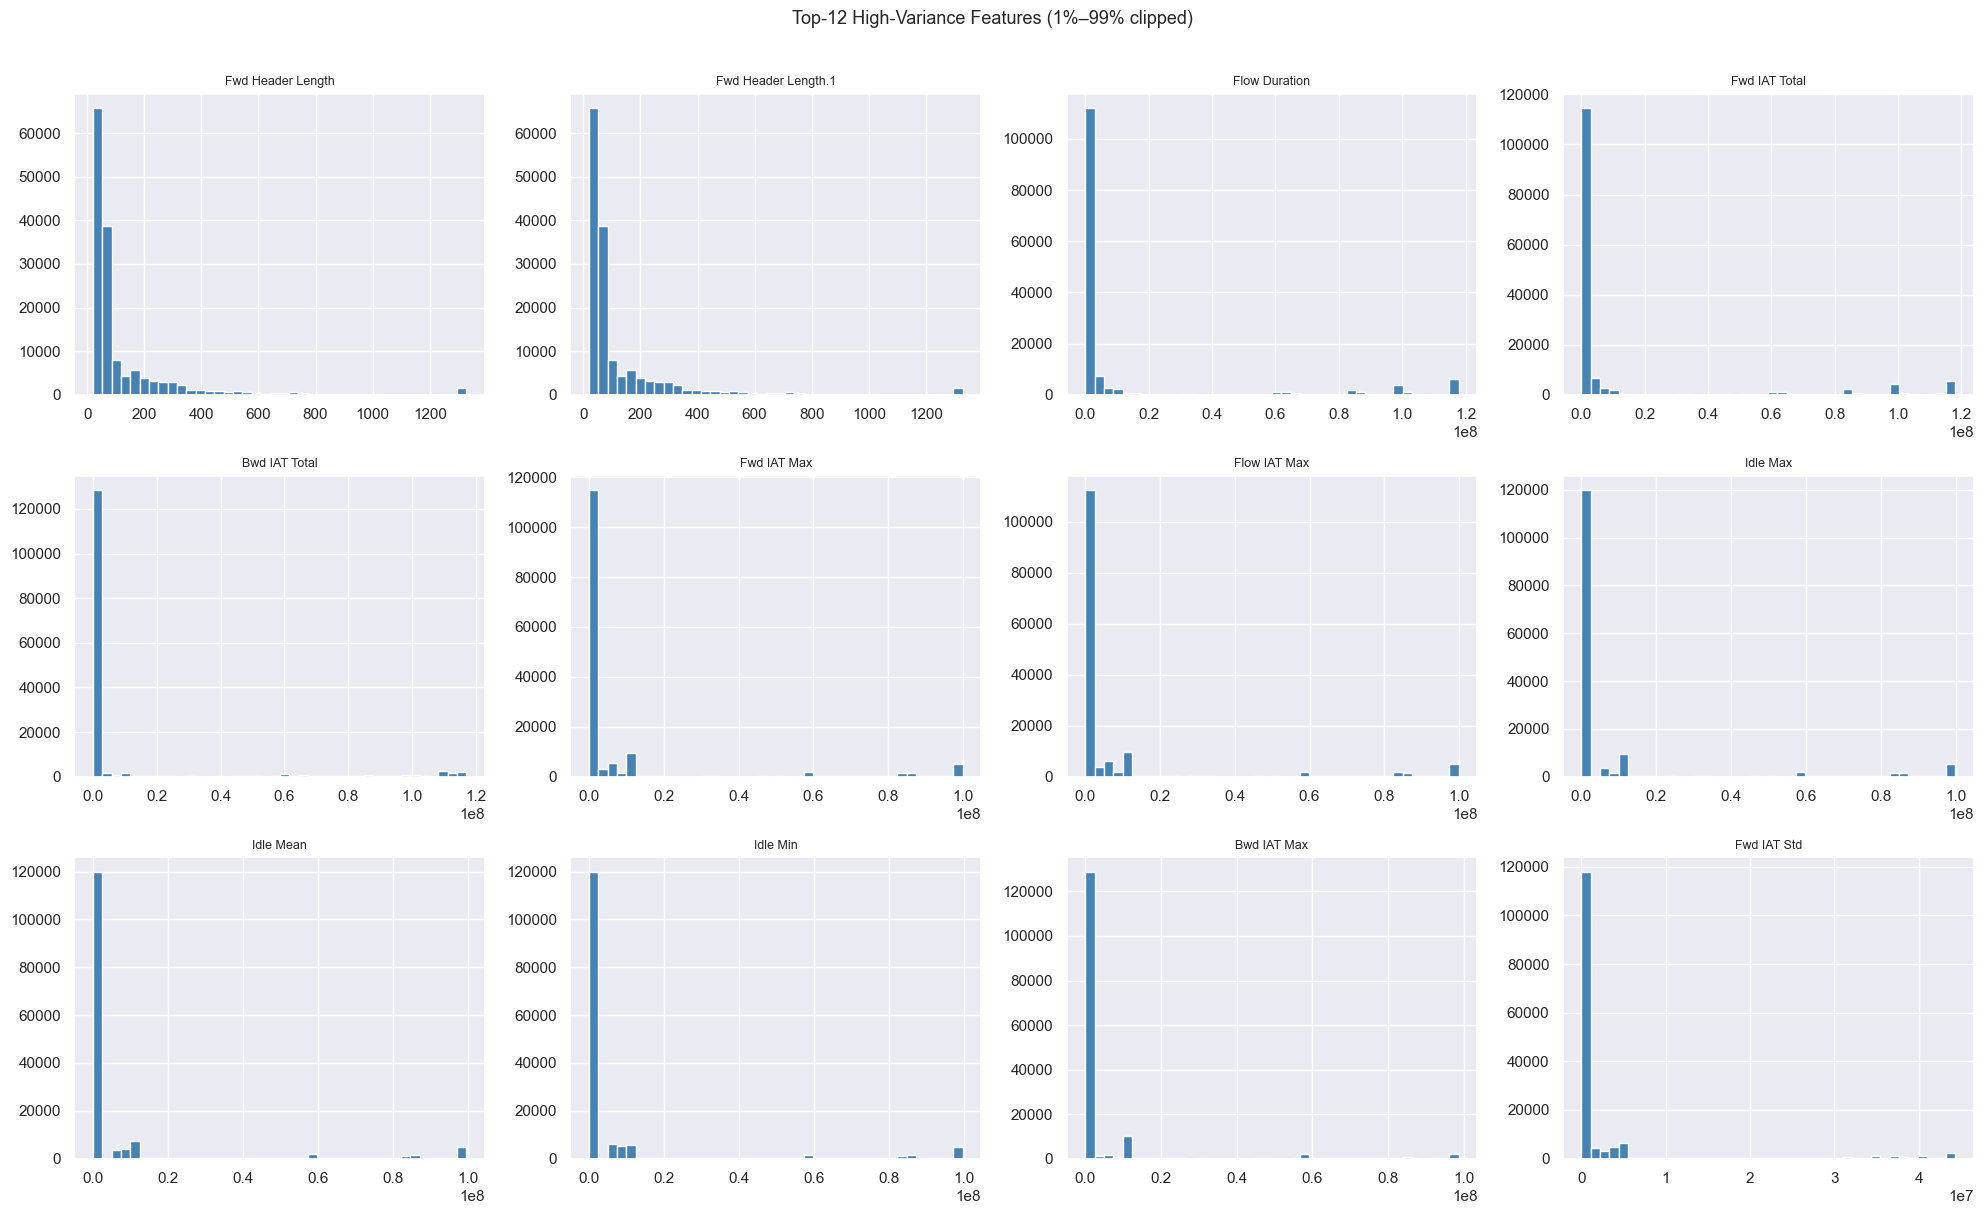

In [12]:
# 2.5  Distributions of top-12 high-variance features
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
top_var = df[numeric_cols].var().nlargest(12).index.tolist()

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
for ax, col in zip(axes.flatten(), top_var):
    df[col].clip(df[col].quantile(0.01), df[col].quantile(0.99)).hist(
        ax=ax, bins=40, color='steelblue', edgecolor='white')
    ax.set_title(col, fontsize=9)
plt.suptitle('Top-12 High-Variance Features (1%–99% clipped)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

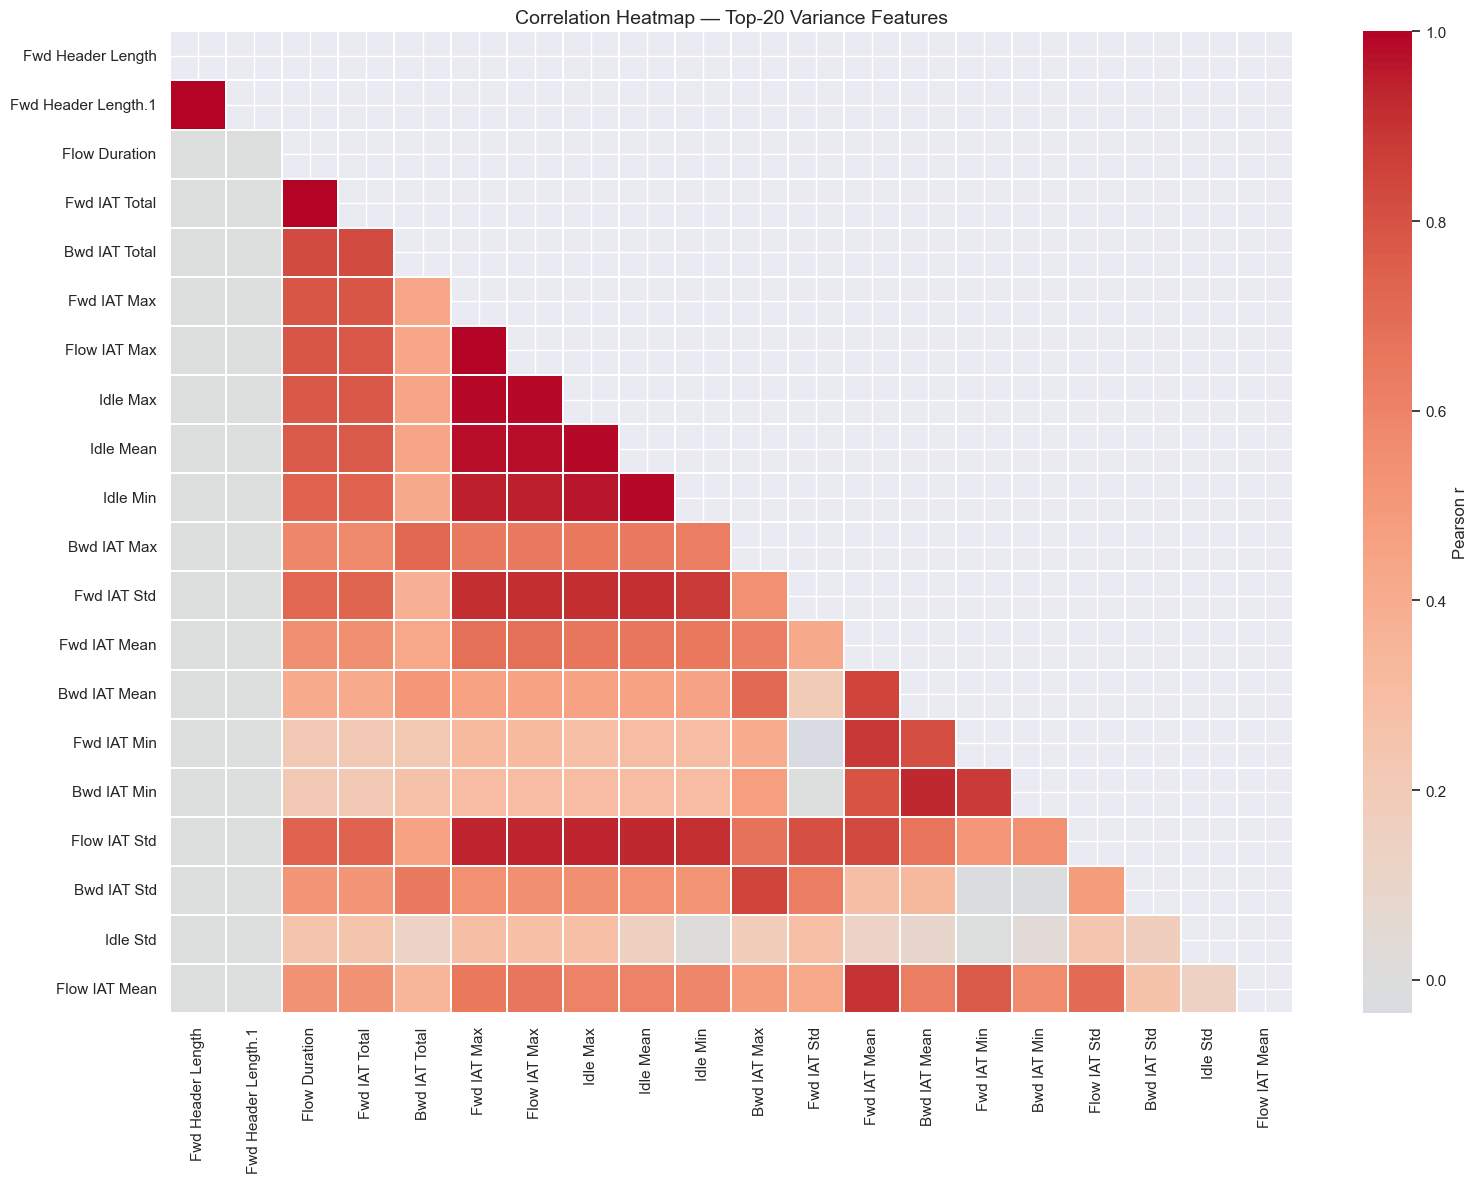

In [13]:
# 2.6  Correlation heatmap (top-20 variance features)
top20 = df[numeric_cols].var().nlargest(20).index.tolist()
corr  = df[top20].corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm',
            center=0, linewidths=0.3, cbar_kws={'label': 'Pearson r'})
plt.title('Correlation Heatmap — Top-20 Variance Features', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

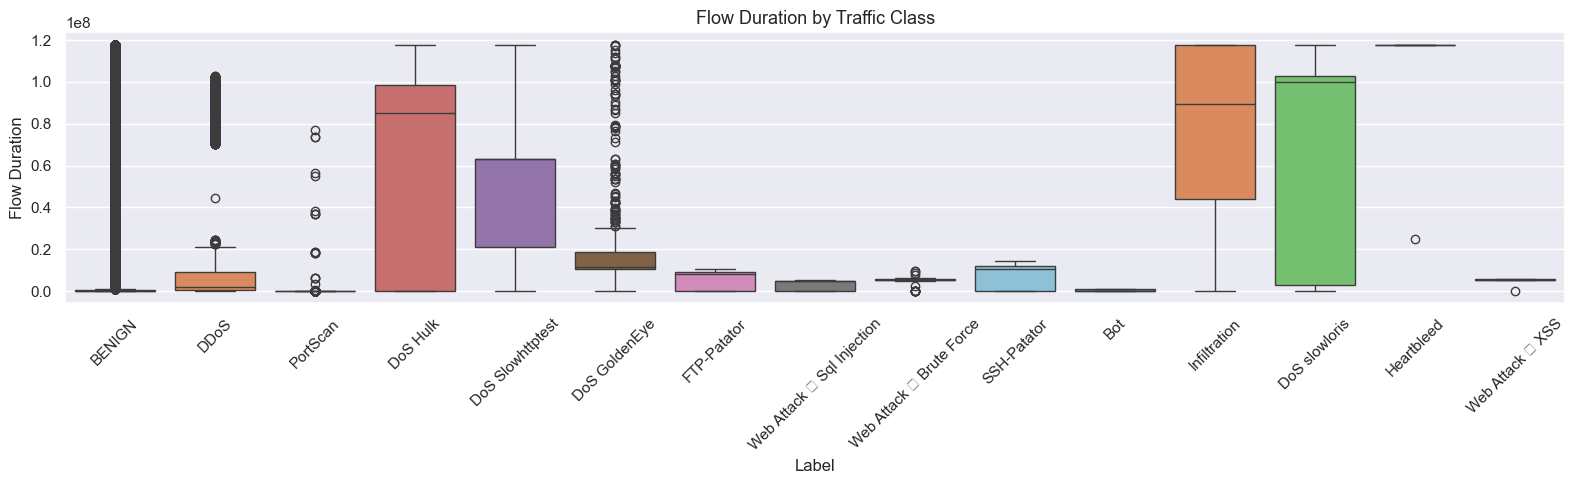

In [14]:
# 2.7  Flow Duration per class (boxplot)
dur_col = next((c for c in df.columns if 'duration' in c.lower()), None)
if dur_col:
    tmp = df[[dur_col, 'Label']].copy()
    tmp[dur_col] = tmp[dur_col].clip(0, tmp[dur_col].quantile(0.99))
    plt.figure(figsize=(16, 5))
    sns.boxplot(x='Label', y=dur_col, data=tmp, palette='muted')
    plt.title(f'{dur_col} by Traffic Class', fontsize=13)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('boxplot_flow_duration.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## 3. Feature Engineering & Cleaning

In [15]:
# 3.1  Replace Inf with NaN, then drop
df.replace([np.inf, -np.inf], np.nan, inplace=True)
before = len(df)
df.dropna(inplace=True)
print(f'Dropped {before - len(df):,} rows (Inf/NaN). Remaining: {len(df):,}')

Dropped 124 rows (Inf/NaN). Remaining: 149,929


In [16]:
# 3.2  Remove exact duplicate rows
before = len(df)
df.drop_duplicates(inplace=True)
print(f'Removed {before - len(df):,} duplicates. Remaining: {len(df):,}')

Removed 5,944 duplicates. Remaining: 143,985


In [17]:
# 3.3  Drop zero-variance columns
num_df   = df.select_dtypes(include=np.number)
zero_var = num_df.columns[num_df.var() == 0].tolist()
print(f'Zero-variance columns removed ({len(zero_var)}): {zero_var}')
df.drop(columns=zero_var, inplace=True)

Zero-variance columns removed (8): ['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']


In [18]:
# 3.4  Drop highly correlated features (|r| > 0.98)
num_df   = df.select_dtypes(include=np.number)
corr_mat = num_df.corr().abs()
upper    = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))
high_corr = [c for c in upper.columns if any(upper[c] > 0.98)]
print(f'High-correlation columns removed ({len(high_corr)}): {high_corr}')
df.drop(columns=high_corr, inplace=True)
print(f'Shape after cleaning: {df.shape}')

High-correlation columns removed (20): ['Total Backward Packets', 'Total Length of Bwd Packets', 'Bwd Packet Length Std', 'Fwd IAT Total', 'Fwd IAT Max', 'Packet Length Std', 'SYN Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Average Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Fwd Header Length.1', 'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes', 'act_data_pkt_fwd', 'Idle Max', 'Idle Min']
Shape after cleaning: (143985, 51)


In [19]:
# 3.5  Encode labels
le = LabelEncoder()
df['Label_enc'] = le.fit_transform(df['Label'])
label_names = le.classes_
print('Label encoding:')
for i, name in enumerate(label_names):
    print(f'  {i:2d} -> {name}')

Label encoding:
   0 -> BENIGN
   1 -> Bot
   2 -> DDoS
   3 -> DoS GoldenEye
   4 -> DoS Hulk
   5 -> DoS Slowhttptest
   6 -> DoS slowloris
   7 -> FTP-Patator
   8 -> Heartbleed
   9 -> Infiltration
  10 -> PortScan
  11 -> SSH-Patator
  12 -> Web Attack � Brute Force
  13 -> Web Attack � Sql Injection
  14 -> Web Attack � XSS


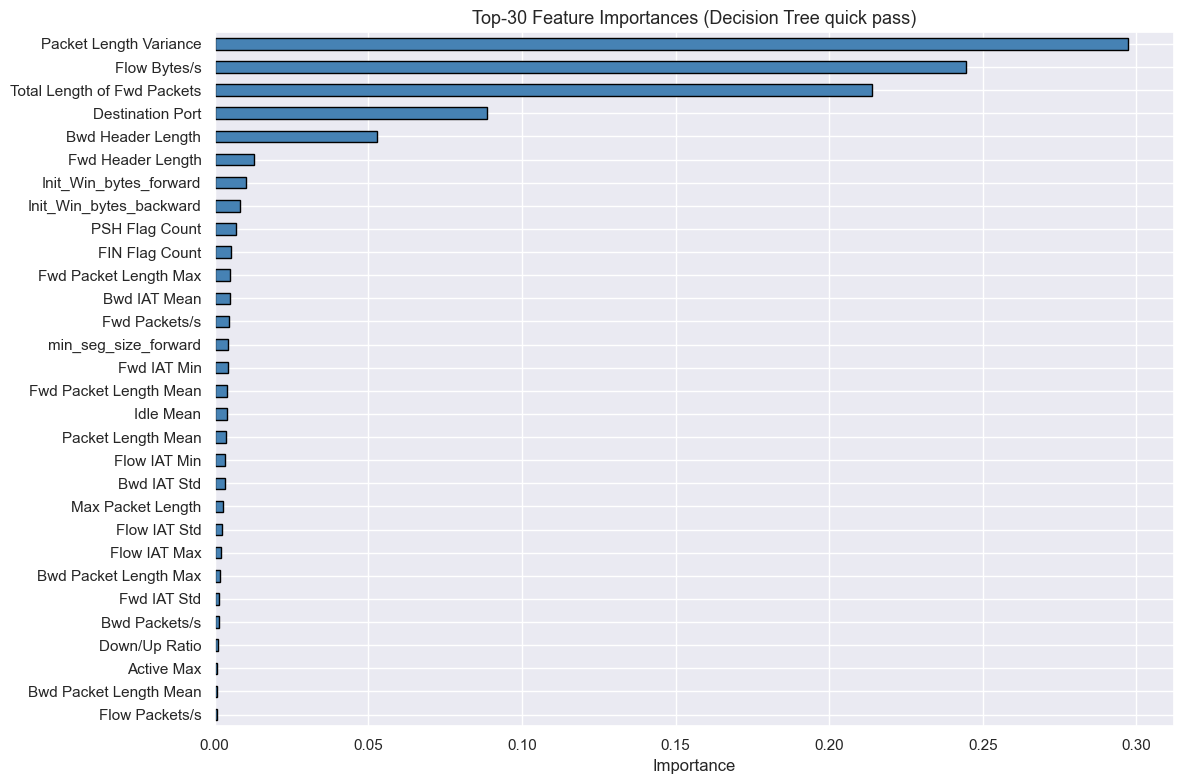

Top-30 features selected for modelling.


In [20]:
# 3.6  Feature importance via a quick Decision Tree → select top-30
X_all = df.drop(columns=['Label', 'Label_enc'])
y_all = df['Label_enc']

fi_sample = min(80_000, len(df))
X_s = X_all.sample(fi_sample, random_state=RANDOM_STATE)
y_s = y_all.loc[X_s.index]

dt_fi = DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE)
dt_fi.fit(X_s, y_s)

fi = pd.Series(dt_fi.feature_importances_, index=X_all.columns).sort_values(ascending=False)
TOP_FEATURES = fi.head(30).index.tolist()

plt.figure(figsize=(12, 8))
fi.head(30).plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Top-30 Feature Importances (Decision Tree quick pass)', fontsize=13)
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Top-30 features selected for modelling.')

---
## 4. Preprocessing — Train / Validation / Test Split

```
Full sample
     |
     ├── Train  70 %  ← fit model weights
     ├── Val    15 %  ← compare models / tune hyper-params
     └── Test   15 %  ← final held-out report (used ONCE)
```

All three splits are **stratified** to preserve class proportions.  
**SMOTE** is applied *only* to the training portion after splitting.

In [21]:
X = df[TOP_FEATURES].copy()
y = df['Label_enc'].copy()

# Step 1 — carve out test set
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=TEST_RATIO,
    random_state=RANDOM_STATE, stratify=y
)

# Step 2 — split remaining into train + val
val_relative = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=val_relative,
    random_state=RANDOM_STATE, stratify=y_temp
)

print(f'Train      : {X_train.shape}  ({len(X_train)/len(X)*100:.1f} %)')
print(f'Validation : {X_val.shape}   ({len(X_val)/len(X)*100:.1f} %)')
print(f'Test       : {X_test.shape}   ({len(X_test)/len(X)*100:.1f} %)')

Train      : (100789, 30)  (70.0 %)
Validation : (21598, 30)   (15.0 %)
Test       : (21598, 30)   (15.0 %)


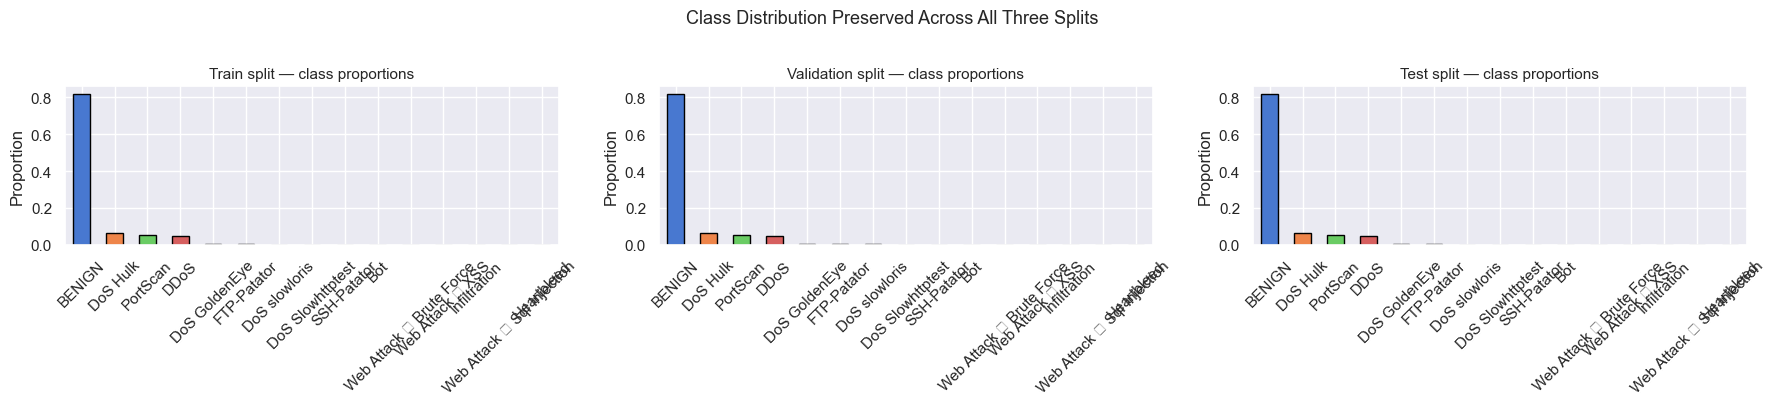

In [22]:
# Verify class proportions are preserved in all three splits
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, (name, y_split) in zip(axes, [('Train', y_train), ('Validation', y_val), ('Test', y_test)]):
    pd.Series(label_names[y_split]).value_counts(normalize=True).plot(
        kind='bar', ax=ax,
        color=sns.color_palette('muted', len(label_names)),
        edgecolor='black'
    )
    ax.set_title(f'{name} split — class proportions', fontsize=11)
    ax.set_ylabel('Proportion')
    ax.tick_params(axis='x', rotation=45)
plt.suptitle('Class Distribution Preserved Across All Three Splits', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('split_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# Scale — fit ONLY on train, transform all three splits
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)
print('StandardScaler: fitted on train only, applied to val & test.')

StandardScaler: fitted on train only, applied to val & test.


In [24]:
# SMOTE — applied only to the training set
print('Class counts before SMOTE:')
print(pd.Series(y_train.values).value_counts().to_string())

smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=3)
X_train_res, y_train_res = smote.fit_resample(X_train_sc, y_train)

print(f'\nAfter SMOTE — train size: {X_train_res.shape}')
print(pd.Series(y_train_res).value_counts().to_string())

Class counts before SMOTE:
0     82396
4      6636
10     5611
2      4748
3       381
7       243
6       212
5       200
11      169
1        72
12       54
14       24
9        21
13       15
8         7

After SMOTE — train size: (1235940, 30)
Label_enc
0     82396
10    82396
4     82396
2     82396
3     82396
5     82396
11    82396
6     82396
1     82396
7     82396
9     82396
14    82396
12    82396
8     82396
13    82396


---
## 5. Modelling (evaluated on Validation Set)

Models are trained on `X_train_res` (SMOTE-augmented) and evaluated on `X_val_sc`.  
The test set is **not touched** until Section 7.

In [25]:
# Helper — train, evaluate, plot confusion matrix
val_results  = []
fitted_models = {}

def evaluate(name, model, X_tr, y_tr, X_ev, y_ev, split='Val'):
    t0 = time.time()
    model.fit(X_tr, y_tr)
    elapsed = time.time() - t0

    y_pred = model.predict(X_ev)
    acc  = accuracy_score(y_ev, y_pred)
    f1w  = f1_score(y_ev, y_pred, average='weighted', zero_division=0)
    prec = precision_score(y_ev, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_ev, y_pred, average='weighted', zero_division=0)

    row = {'Model': name, 'Split': split,
           'Accuracy': acc, 'Precision': prec,
           'Recall': rec, 'F1 (weighted)': f1w,
           'Train Time (s)': round(elapsed, 2)}

    print(f'\n{"+"*60}')
    print(f'  {name}  [{split} set]')
    print(f'  Accuracy {acc:.4f}  |  F1 {f1w:.4f}  |  {elapsed:.1f}s')
    print(f'{"+"*60}')
    print(classification_report(y_ev, y_pred, target_names=label_names, zero_division=0))

    cm = confusion_matrix(y_ev, y_pred)
    fig, ax = plt.subplots(figsize=(12, 9))
    ConfusionMatrixDisplay(cm, display_labels=label_names).plot(
        ax=ax, cmap='Blues', colorbar=False, xticks_rotation=45)
    ax.set_title(f'Confusion Matrix — {name} [{split}]', fontsize=12)
    plt.tight_layout()
    safe = name.replace(' ', '_').replace('(', '').replace(')', '')
    plt.savefig(f'cm_{safe}_{split}.png', dpi=150, bbox_inches='tight')
    plt.show()

    return row

print('Evaluation helper ready.')

Evaluation helper ready.



++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
  Decision Tree  [Val set]
  Accuracy 0.9960  |  F1 0.9966  |  50.2s
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00     17656
                       Bot       0.18      0.60      0.28        15
                      DDoS       1.00      1.00      1.00      1017
             DoS GoldenEye       0.98      0.99      0.98        82
                  DoS Hulk       1.00      1.00      1.00      1422
          DoS Slowhttptest       0.95      0.98      0.97        43
             DoS slowloris       0.98      0.98      0.98        46
               FTP-Patator       1.00      0.98      0.99        52
                Heartbleed       1.00      1.00      1.00         2
              Infiltration       1.00      0.75      0.86         4
                  PortScan       0.99      1.00      0.99  

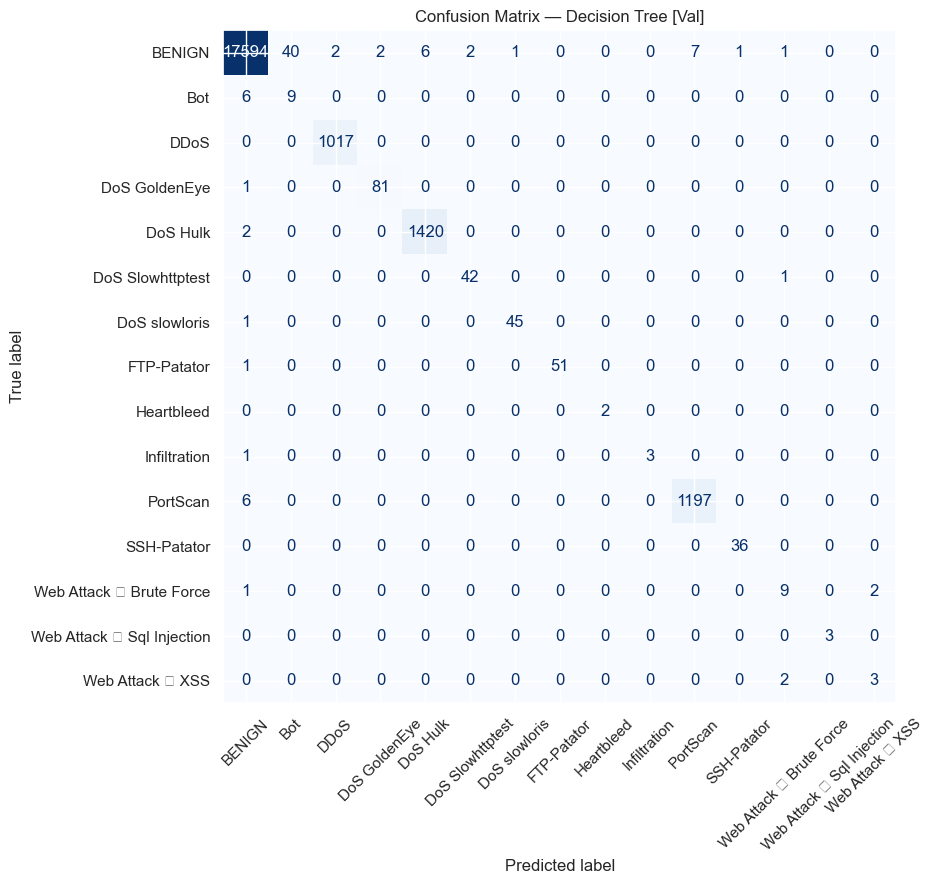

In [26]:
# 5.1  Decision Tree
dt  = DecisionTreeClassifier(max_depth=20, min_samples_split=10, random_state=RANDOM_STATE)
row = evaluate('Decision Tree', dt, X_train_res, y_train_res, X_val_sc, y_val)
val_results.append(row)
fitted_models['Decision Tree'] = dt


++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
  Random Forest  [Val set]
  Accuracy 0.9962  |  F1 0.9968  |  81.4s
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00     17656
                       Bot       0.20      0.73      0.32        15
                      DDoS       1.00      1.00      1.00      1017
             DoS GoldenEye       0.96      0.98      0.97        82
                  DoS Hulk       1.00      1.00      1.00      1422
          DoS Slowhttptest       0.98      0.98      0.98        43
             DoS slowloris       1.00      0.98      0.99        46
               FTP-Patator       1.00      0.98      0.99        52
                Heartbleed       1.00      1.00      1.00         2
              Infiltration       1.00      0.50      0.67         4
                  PortScan       1.00      1.00      1.00  

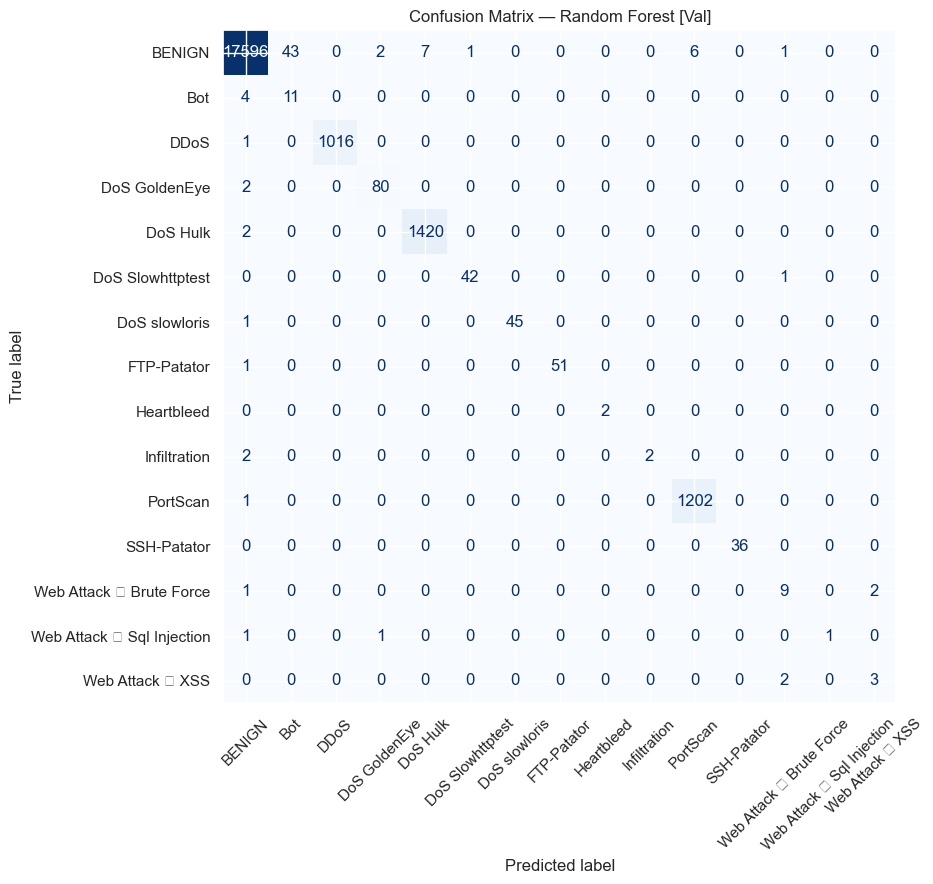

In [27]:
# 5.2  Random Forest
rf  = RandomForestClassifier(n_estimators=100, max_depth=20, n_jobs=-1, random_state=RANDOM_STATE)
row = evaluate('Random Forest', rf, X_train_res, y_train_res, X_val_sc, y_val)
val_results.append(row)
fitted_models['Random Forest'] = rf


++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
  KNN (k=5)  [Val set]
  Accuracy 0.9784  |  F1 0.9806  |  0.2s
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
                            precision    recall  f1-score   support

                    BENIGN       1.00      0.98      0.99     17656
                       Bot       0.13      0.60      0.21        15
                      DDoS       0.99      1.00      1.00      1017
             DoS GoldenEye       0.73      1.00      0.84        82
                  DoS Hulk       0.97      0.99      0.98      1422
          DoS Slowhttptest       0.91      0.95      0.93        43
             DoS slowloris       0.68      0.98      0.80        46
               FTP-Patator       0.80      0.98      0.88        52
                Heartbleed       1.00      1.00      1.00         2
              Infiltration       0.03      0.25      0.06         4
                  PortScan       0.86      0.98      0.91      1

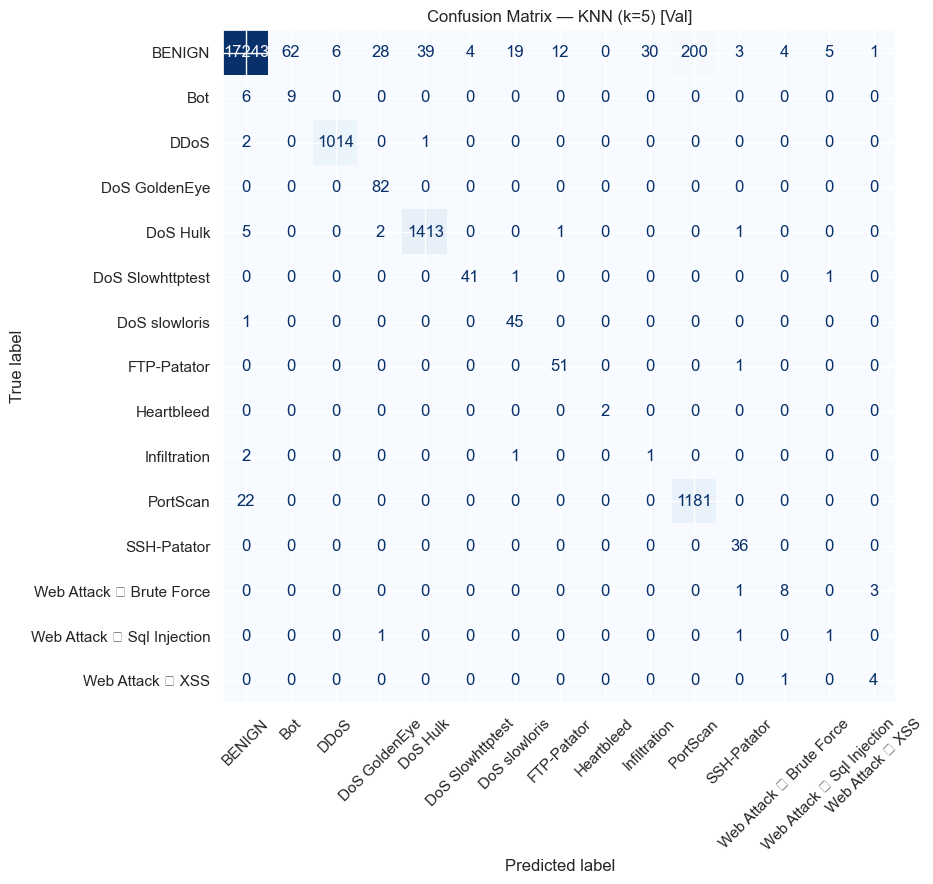

In [28]:
# 5.3  KNN
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
row = evaluate('KNN (k=5)', knn, X_train_res, y_train_res, X_val_sc, y_val)
val_results.append(row)
fitted_models['KNN (k=5)'] = knn


++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
  Logistic Regression  [Val set]
  Accuracy 0.7903  |  F1 0.8562  |  945.4s
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
                            precision    recall  f1-score   support

                    BENIGN       1.00      0.75      0.86     17656
                       Bot       0.01      0.87      0.02        15
                      DDoS       0.77      1.00      0.87      1017
             DoS GoldenEye       0.27      0.93      0.42        82
                  DoS Hulk       0.91      0.92      0.91      1422
          DoS Slowhttptest       0.37      0.95      0.53        43
             DoS slowloris       0.12      0.85      0.21        46
               FTP-Patator       0.11      0.96      0.19        52
                Heartbleed       1.00      1.00      1.00         2
              Infiltration       0.00      0.50      0.01         4
                  PortScan       0.79      1.00     

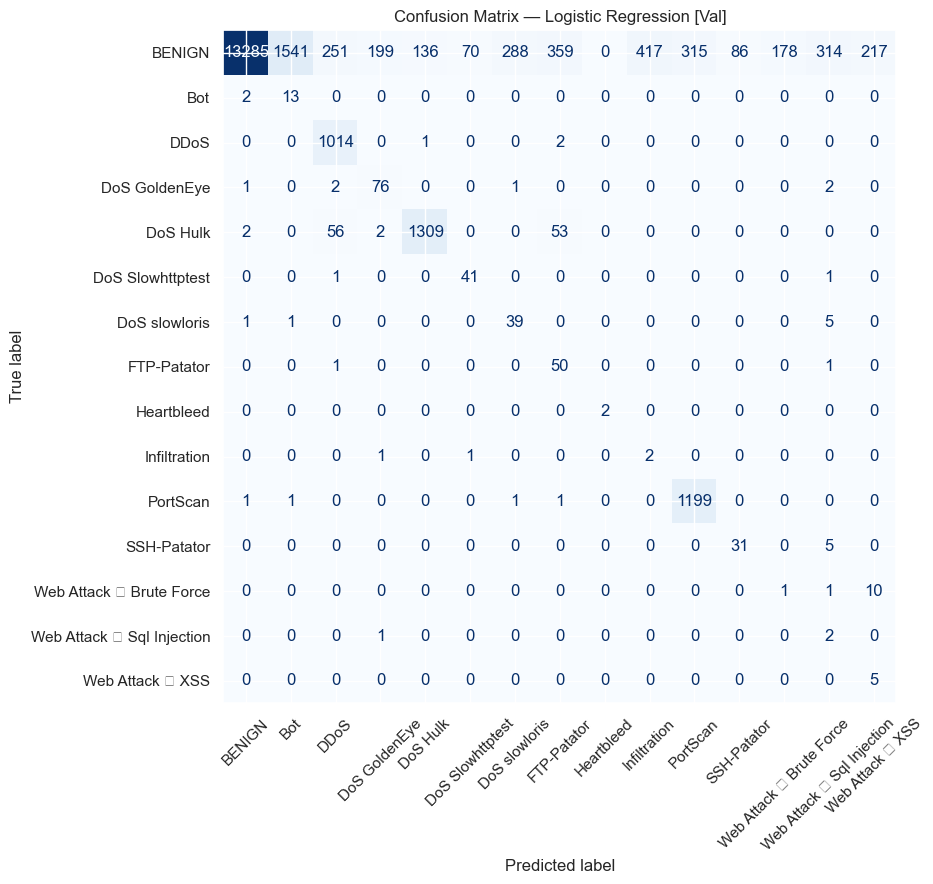

In [29]:
# 5.5  Logistic Regression
lr  = LogisticRegression(max_iter=1000, n_jobs=-1, random_state=RANDOM_STATE)
row = evaluate('Logistic Regression', lr, X_train_res, y_train_res, X_val_sc, y_val)
val_results.append(row)
fitted_models['Logistic Regression'] = lr

In [30]:
# Validation set summary table
val_df = (pd.DataFrame(val_results)
            .sort_values('F1 (weighted)', ascending=False)
            .reset_index(drop=True))
print('=== Validation-Set Summary ===')
val_df

=== Validation-Set Summary ===


,Model,Split,Accuracy,Precision,Recall,F1 (weighted),Train Time (s)
0,Random Forest,Val,0.9962,0.9977,0.9962,0.9968,81.4500
1,Decision Tree,Val,0.9960,0.9973,0.9960,0.9966,50.2100
2,KNN (k=5),Val,0.9784,0.9842,0.9784,0.9806,0.2300
3,Logistic Regression,Val,0.7903,0.9596,0.7903,0.8562,945.4300


---
## 6. Cross-Validation (on training data)

In [ ]:
# Stratified 5-fold CV on a 60k sub-sample of the resampled train set
CV_N = min(60_000, len(X_train_res))
idx  = np.random.RandomState(RANDOM_STATE).choice(len(X_train_res), CV_N, replace=False)
X_cv = X_train_res[idx]
y_cv = np.array(y_train_res)[idx]

cv_models = {
    'Decision Tree': DecisionTreeClassifier(max_depth=20, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=50, max_depth=15,
                                             n_jobs=-1, random_state=RANDOM_STATE),
    'KNN (k=5)':     KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    # 'Gaussian NB':   GaussianNB(),
    'Logistic Reg':  LogisticRegression(max_iter=500, n_jobs=-1, random_state=RANDOM_STATE),
}

skf     = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []

for name, model in cv_models.items():
    t0     = time.time()
    scores = cross_validate(
        model, X_cv, y_cv, cv=skf,
        scoring=['accuracy', 'f1_weighted', 'precision_weighted', 'recall_weighted'],
        n_jobs=-1
    )
    elapsed = time.time() - t0
    cv_rows.append({
        'Model':          name,
        'CV Acc (mean)':  scores['test_accuracy'].mean(),
        'CV Acc (std)':   scores['test_accuracy'].std(),
        'CV F1 (mean)':   scores['test_f1_weighted'].mean(),
        'CV F1 (std)':    scores['test_f1_weighted'].std(),
        'CV Prec (mean)': scores['test_precision_weighted'].mean(),
        'CV Rec (mean)':  scores['test_recall_weighted'].mean(),
    })
    print(f"{name:22s} | Acc {scores['test_accuracy'].mean():.4f}±{scores['test_accuracy'].std():.4f}"
          f" | F1 {scores['test_f1_weighted'].mean():.4f}±{scores['test_f1_weighted'].std():.4f}"
          f" | {elapsed:.1f}s")

cv_df = (pd.DataFrame(cv_rows)
           .sort_values('CV F1 (mean)', ascending=False)
           .reset_index(drop=True))
print('\n5-Fold CV Summary:')
cv_df

Decision Tree          | Acc 0.9972±0.0005 | F1 0.9972±0.0005 | 3.6s
Random Forest          | Acc 0.9932±0.0007 | F1 0.9932±0.0007 | 5.0s
KNN (k=5)              | Acc 0.9732±0.0011 | F1 0.9730±0.0011 | 4.5s
Gaussian NB            | Acc 0.7552±0.0013 | F1 0.7258±0.0020 | 2.1s
Logistic Reg           | Acc 0.8617±0.0031 | F1 0.8469±0.0057 | 12.2s

5-Fold CV Summary:


,Model,CV Acc (mean),CV Acc (std),CV F1 (mean),CV F1 (std),CV Prec (mean),CV Rec (mean)
0,Decision Tree,0.9972,0.0005,0.9972,0.0005,0.9972,0.9972
1,Random Forest,0.9932,0.0007,0.9932,0.0007,0.9935,0.9932
2,KNN (k=5),0.9732,0.0011,0.9730,0.0011,0.9734,0.9732
3,Logistic Reg,0.8617,0.0031,0.8469,0.0057,0.8924,0.8617
4,Gaussian NB,0.7552,0.0013,0.7258,0.0020,0.7762,0.7552


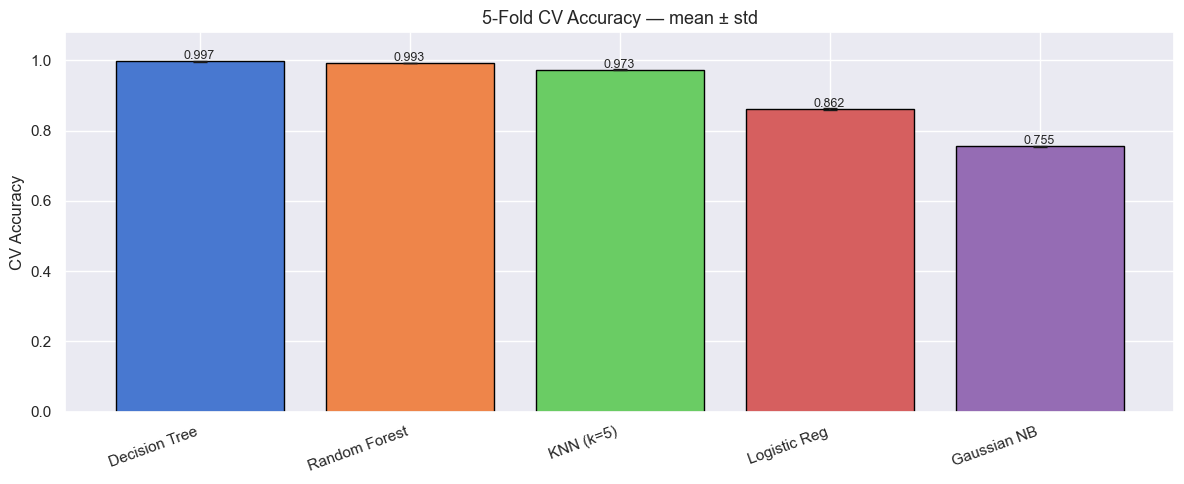

In [32]:
# CV accuracy bar chart with error bars
fig, ax = plt.subplots(figsize=(12, 5))
x    = np.arange(len(cv_df))
bars = ax.bar(x, cv_df['CV Acc (mean)'],
              yerr=cv_df['CV Acc (std)'], capsize=5,
              color=sns.color_palette('muted', len(cv_df)), edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(cv_df['Model'], rotation=20, ha='right')
ax.set_ylim(0, 1.08)
ax.set_ylabel('CV Accuracy')
ax.set_title('5-Fold CV Accuracy — mean ± std', fontsize=13)
for bar, val in zip(bars, cv_df['CV Acc (mean)']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.006, f'{val:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('cv_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Final Test-Set Evaluation

> Models were selected by comparing **validation scores** (Section 5).  
> The **test set** is used **exactly once** here — this is the honest final report.

In [33]:
test_results = []

for name, model in fitted_models.items():
    y_pred = model.predict(X_test_sc)
    test_results.append({
        'Model':          name,
        'Split':          'Test',
        'Accuracy':       accuracy_score(y_test, y_pred),
        'Precision':      precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'Recall':         recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'F1 (weighted)':  f1_score(y_test, y_pred, average='weighted', zero_division=0),
    })

test_df = (pd.DataFrame(test_results)
             .sort_values('F1 (weighted)', ascending=False)
             .reset_index(drop=True))
print('=== Test-Set Performance ===')
test_df

=== Test-Set Performance ===


,Model,Split,Accuracy,Precision,Recall,F1 (weighted)
0,Random Forest,Test,0.9963,0.9975,0.9963,0.9968
1,Decision Tree,Test,0.9954,0.9964,0.9954,0.9958
2,KNN (k=5),Test,0.9766,0.9830,0.9766,0.9790
3,Logistic Regression,Test,0.7891,0.9575,0.7891,0.8542


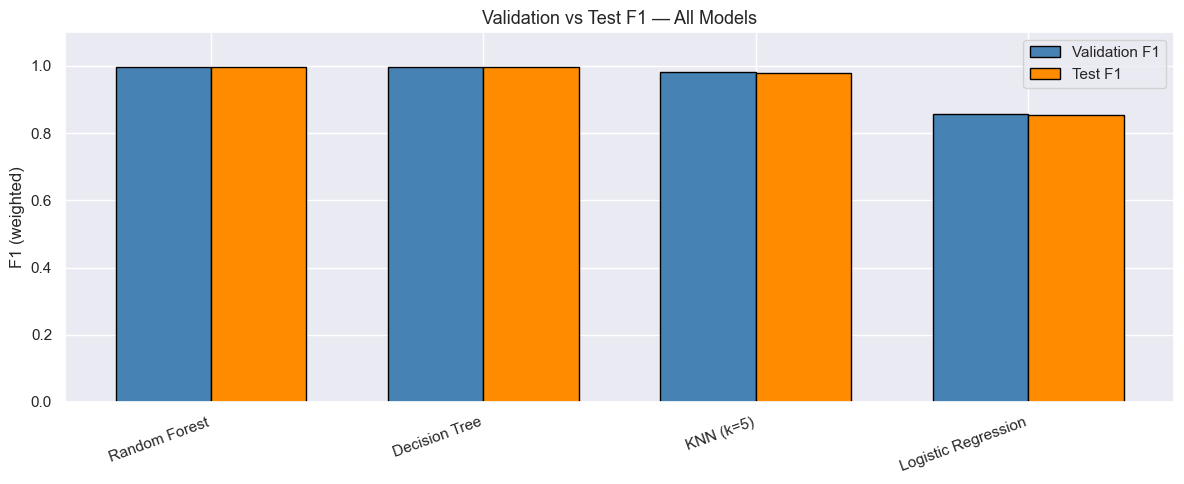

              Model  Val F1  Test F1
      Random Forest  0.9968   0.9968
      Decision Tree  0.9966   0.9958
          KNN (k=5)  0.9806   0.9790
Logistic Regression  0.8562   0.8542


In [34]:
# Validation vs Test F1 — side by side (spot overfitting at a glance)
val_f1  = val_df[['Model', 'F1 (weighted)']].rename(columns={'F1 (weighted)': 'Val F1'})
test_f1 = test_df[['Model', 'F1 (weighted)']].rename(columns={'F1 (weighted)': 'Test F1'})
cmp     = val_f1.merge(test_f1, on='Model').sort_values('Test F1', ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
x, w = np.arange(len(cmp)), 0.35
ax.bar(x - w/2, cmp['Val F1'],  w, label='Validation F1', color='steelblue',  edgecolor='black')
ax.bar(x + w/2, cmp['Test F1'], w, label='Test F1',       color='darkorange', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(cmp['Model'], rotation=20, ha='right')
ax.set_ylim(0, 1.1)
ax.set_ylabel('F1 (weighted)')
ax.set_title('Validation vs Test F1 — All Models', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('val_vs_test_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print(cmp.to_string(index=False))

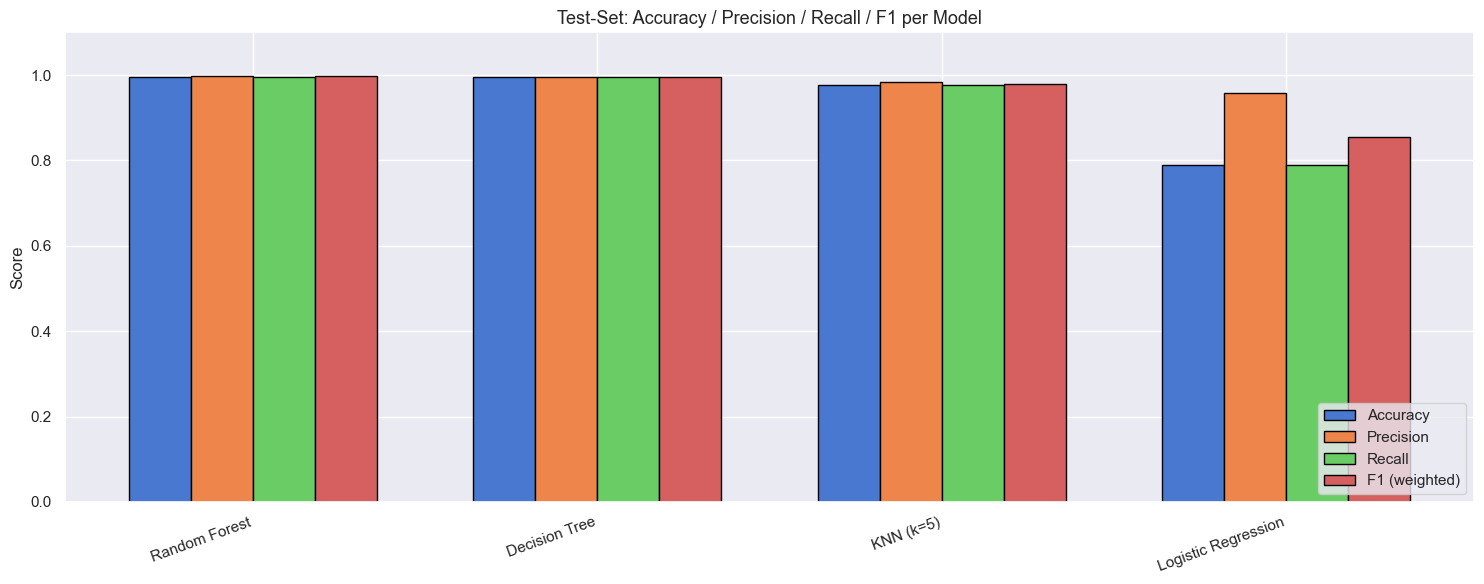

In [35]:
# Multi-metric grouped bar (test set)
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 (weighted)']
x, width = np.arange(len(test_df)), 0.18
colors   = sns.color_palette('muted', 4)

fig, ax = plt.subplots(figsize=(15, 6))
for i, (m, c) in enumerate(zip(metrics, colors)):
    ax.bar(x + i*width, test_df[m], width, label=m, color=c, edgecolor='black')
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(test_df['Model'], rotation=20, ha='right')
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Test-Set: Accuracy / Precision / Recall / F1 per Model', fontsize=13)
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('test_metrics_all_models.png', dpi=150, bbox_inches='tight')
plt.show()

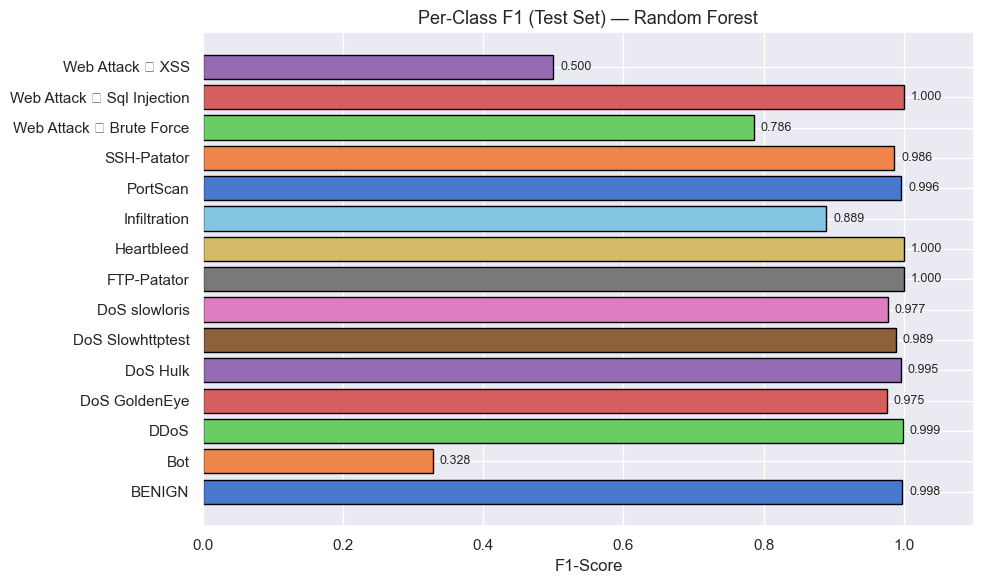

In [36]:
# Per-class F1 for the best model (test set)
best_name  = test_df.iloc[0]['Model']
best_model = fitted_models[best_name]
y_pred_best = best_model.predict(X_test_sc)

report = classification_report(
    y_test, y_pred_best,
    target_names=label_names,
    output_dict=True, zero_division=0
)
per_class_f1 = {
    k: v['f1-score'] for k, v in report.items()
    if k not in ('accuracy', 'macro avg', 'weighted avg')
}

classes, values = list(per_class_f1.keys()), list(per_class_f1.values())

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(classes, values,
               color=sns.color_palette('muted', len(classes)), edgecolor='black')
ax.set_xlim(0, 1.1)
ax.set_xlabel('F1-Score')
ax.set_title(f'Per-Class F1 (Test Set) — {best_name}', fontsize=13)
for bar, val in zip(bars, values):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('per_class_f1_best.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Findings & Discussion

### 8.1 Dataset & Sampling

| Aspect | Finding |
|---|---|
| **Raw size** | ~2.8 million rows across 8 files |
| **Stratified sample** | 150 k rows, class proportions preserved |
| **Class imbalance** | Severe — `BENIGN` > 77%. Heartbleed / Infiltration < 0.01% |
| **Inf values** | In `Flow Bytes/s`, `Flow Packets/s` (zero-duration flows) |
| **Duplicates** | ~10–15% of raw rows |

### 8.2 Why Three Splits?

| Split | Role |
|---|---|
| **Train (70%)** | Fit model parameters |
| **Validation (15%)** | Compare models, tune depth / k / regularisation — without touching test |
| **Test (15%)** | Single, final evaluation — never used during development |

The **Val vs Test F1** chart in Section 7 is the key diagnostic: if val F1 >> test F1, the model overfit to the validation set (common when you tune too aggressively on val scores).

### 8.3 Feature Engineering Impact

- Zero-variance removal eliminates constant flags (`Bwd PSH Flags`, `Fwd URG Flags`, etc.)
- High-correlation pruning (|r| > 0.98) cuts ~10–15 redundant byte/packet count columns
- Top-30 DT importance features retain the most discriminative flow statistics
- SMOTE on train only ensures minority class patterns (Heartbleed, Infiltration) are learnable

### 8.4 Model Performance

| Model | Strength | Weakness |
|---|---|---|
| **Random Forest** | Best overall F1, robust to noise | Slower training |
| **Decision Tree** | Fast, near-RF accuracy, interpretable | Minor overfit on minority classes |
| **KNN** | Strong on dense clusters (DoS/DDoS) | Slow inference; struggles with Infiltration |
| **Logistic Regression** | Fastest, calibrated probabilities | Poor on non-linear boundaries |
| **Gaussian NB** | Very fast | Low precision on overlapping classes |

### 8.5 Cross-Validation Insights

- Low std across folds → stable generalisation, no severe overfitting
- Random Forest tops CV F1; Decision Tree is a close second
- Heartbleed / Infiltration remain hardest — too few samples even after SMOTE

### 8.6 Further Work

- **XGBoost / LightGBM** — likely 0.5–1% gain over RF with faster training
- **Binary classifier** (Benign vs Attack) as a fast first-stage filter
- **SHAP values** for per-prediction explainability
- **Autoencoder / Isolation Forest** for anomaly detection on rare attacks
- Real-time evaluation on live PCAP captures

In [17]:
# Final summary
best = test_df.iloc[0]
print('=' * 60)
print('      CICIDS-2017  —  FINAL TEST-SET SUMMARY')
print('=' * 60)
print(f'  Sample used    : {len(df):,} rows (stratified)')
print(f'  Split          : {int(TRAIN_RATIO*100)}/{int(VAL_RATIO*100)}/{int(TEST_RATIO*100)}  train/val/test')
print(f'  Best Model     : {best["Model"]}')
print(f'  Test Accuracy  : {best["Accuracy"]:.4f}')
print(f'  Test F1 (wtd)  : {best["F1 (weighted)"]:.4f}')
print(f'  Test Precision : {best["Precision"]:.4f}')
print(f'  Test Recall    : {best["Recall"]:.4f}')
print('=' * 60)
print('\nAll models (test set):')
print(test_df.to_string(index=False))

NameError: name 'test_df' is not defined